# Example for bssunfold package with features 

- interpolation
- plot

In [1]:
# %pip install bssunfold pandas numpy matplotlib

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from bssunfold import Detector,RF_GSF, RF_LANL

## Load the response functions file for the BSS
- first column: Energy in MeV
- other columns: detector responses for the set of moderator spheres

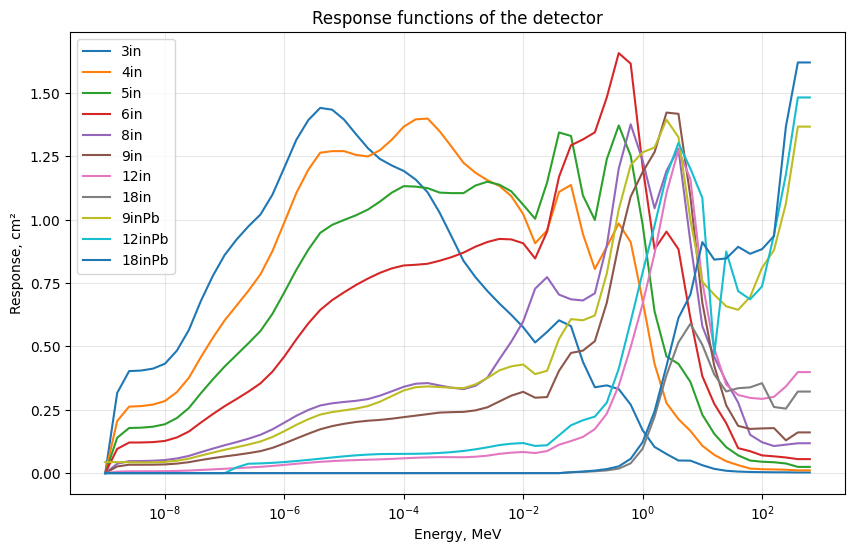

In [3]:
det = Detector(RF_LANL)
det.plot_response_functions(
    #  save_to='rf.png', dpi=300  # save to file
    )

In [4]:
# reference spectrum ISO Cf-252.
reference_spectrum = {
    "E_MeV": [
        1e-09,
        1.5848931924611136e-09,
        2.5118864315095803e-09,
        3.981071705534973e-09,
        6.309573444801934e-09,
        1e-08,
        1.5848931924611143e-08,
        2.511886431509581e-08,
        3.9810717055349736e-08,
        6.309573444801934e-08,
        1.0000000000000001e-07,
        1.5848931924611143e-07,
        2.5118864315095823e-07,
        3.9810717055349735e-07,
        6.309573444801937e-07,
        1.0000000000000002e-06,
        1.584893192461114e-06,
        2.5118864315095823e-06,
        3.981071705534973e-06,
        6.309573444801937e-06,
        1e-05,
        1.584893192461114e-05,
        2.5118864315095822e-05,
        3.9810717055349776e-05,
        6.309573444801943e-05,
        0.0001,
        0.00015848931924611142,
        0.0002511886431509582,
        0.0003981071705534978,
        0.0006309573444801943,
        0.001,
        0.0015848931924611143,
        0.0025118864315095825,
        0.003981071705534978,
        0.006309573444801942,
        0.01,
        0.01584893192461114,
        0.025118864315095826,
        0.039810717055349776,
        0.06309573444801943,
        0.1,
        0.15848931924611173,
        0.25118864315095824,
        0.3981071705534969,
        0.6309573444801944,
        1.0,
        1.5848931924611174,
        2.5118864315095824,
        3.9810717055349856,
        6.309573444801943,
        10.0,
        15.848931924611176,
        25.118864315095824,
        39.810717055349855,
        63.09573444801943,
        100.0,
        158.48931924611173,
        251.18864315095823,
        398.1071705534986,
        630.9573444801944,
    ],
    "Phi": [
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0002193244132568562,
        0.000922,
        0.0017977302145640818,
        0.0033934229230273556,
        0.00638236969883396,
        0.01212580290671056,
        0.0237,
        0.04468185467401807,
        0.0822779218679577,
        0.1450462719353082,
        0.2413649401952857,
        0.359,
        0.45221093414611185,
        0.4338707690763234,
        0.2708850368693928,
        0.0856762250762,
        0.00427,
        0.0004258199483775139,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
    ],
}

In [5]:
readings = det.get_effective_readings_for_spectra(reference_spectrum)
readings

{'3in': 0.339934800115256,
 '4in': 1.1540267733387468,
 '5in': 1.6949642349997989,
 '6in': 2.414902989013657,
 '8in': 2.506955384471506,
 '9in': 2.5925178363346078,
 '12in': 1.7633955277542266,
 '18in': 0.509007911100528,
 '9inPb': 2.654290882145632,
 '12inPb': 1.9428831470830863,
 '18inPb': 0.5878222748066373}

## Unfold the spectrum


In [6]:
noise_level = 0.002  # 1% of the total readings
n_montecarlo = 30  # number of Monte Carlo simulations

results = {
    "tikhonov+manual": det.unfold_cvxpy(
        readings,
        solver="ECOS",
        regularization=1e-4,
        noise_level=noise_level,
        n_montecarlo=n_montecarlo,
        save_result=False,
        calculate_errors=True,
    ),
    "tikhonov+gcv": det.unfold_cvxpy(
        readings,
        solver="ECOS",
        regularization_method="gcv",
        noise_level=noise_level,
        n_montecarlo=n_montecarlo,
        save_result=False,
        calculate_errors=True,
    ),
    "tikhonov+dp": det.unfold_cvxpy(
        readings,
        solver="ECOS",
        regularization_method="dp",
        noise_level=noise_level,
        n_montecarlo=n_montecarlo,
        save_result=False,
        calculate_errors=True,
    ),
    "tikhonov+manual": det.unfold_cvxpy(
        readings,
        solver="ECOS",
        regularization_method="manual",
        noise_level=noise_level,
        n_montecarlo=n_montecarlo,
        save_result=False,
        calculate_errors=True,
    ),
}

Status: optimal
Objective value: 8.297476737634119e-05
Residual norm: 0.000000
Calculating uncertainty with Monte-Carlo...
Status: optimal
Objective value: 0.003011592758499377
Status: optimal
Objective value: 0.0014039994197327056
Status: optimal
Objective value: 0.001214635397475424
Status: optimal
Objective value: 0.0013793355282433611
Status: optimal
Objective value: 0.002324957675657716
Status: optimal
Objective value: 8.438324976439616e-05
Status: optimal
Objective value: 0.0033419046864269558
Status: optimal
Objective value: 0.005068075287517729
Status: optimal
Objective value: 0.004277863030809873
Status: optimal
Objective value: 0.000599943682083824
Status: optimal
Objective value: 9.394856781639433e-05
Status: optimal
Objective value: 0.00032363202362083426
Status: optimal
Objective value: 9.076135764746932e-05
Status: optimal
Objective value: 8.422721795251117e-05
Status: optimal
Objective value: 0.009017173686912915
Status: optimal
Objective value: 0.00026818470230578485
St

## Plot results

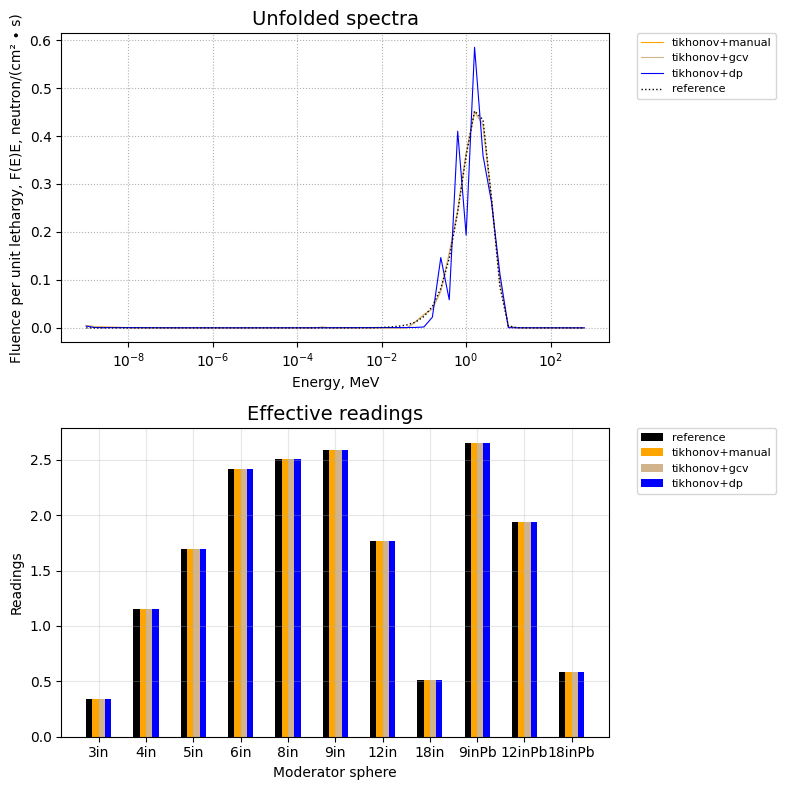

In [7]:
fig, ax = plt.subplots(2, 1, figsize=(8, 8))
methods = list(results.keys())
all_labels = ["reference"] + methods

colors = ["black", "orange", "tan", "blue", "indianred"]
# Первый график (спектры)
for i, method in enumerate(results.keys()):
    ax[0].plot(
        results[method]["energy"],
        results[method]["spectrum"],
        label=method,
        color=colors[i + 1],
        ls="-",
        linewidth=0.8,
        alpha=1,
    )

ax[0].plot(
    reference_spectrum["E_MeV"],
    reference_spectrum["Phi"],
    label="reference",
    linewidth=1,
    linestyle=":",
    color=colors[0],
)

ax[0].set_xlabel("Energy, MeV")
ax[0].set_ylabel("Fluence per unit lethargy, F(E)E, neutron/(cm² ∙ s)")
ax[0].set_xscale("log")
ax[0].legend(
    bbox_to_anchor=(1.05, 1), loc="upper left", borderaxespad=0.0, fontsize=8
)
ax[0].grid(True, which="both", ls=":")
ax[0].set_title(f"Unfolded spectra", fontsize=14)


# Второй график (столбчатая диаграмма)
data_sources = {"reference": list(readings.values())}
for method in results.keys():
    data_sources[method] = [
        results[method]["effective_readings"][det] for det in readings.keys()
    ]

labels = list(readings.keys())
x = np.arange(len(labels))
width = 0.8 / (len(data_sources) * 1.5)
n_bars = len(data_sources)

for i, (label, values) in enumerate(data_sources.items()):
    offset = (i - n_bars / 2 + 0.5) * width

    ax[1].bar(x + offset, values, width, label=label, alpha=1, color=colors[i])


ax[1].set_xticks(x, labels)
ax[1].set_xlabel("Moderator sphere")
ax[1].set_ylabel("Readings")
# ax[1].set_yscale('log')
ax[1].set_title("Effective readings", fontsize=14)
ax[1].legend(
    bbox_to_anchor=(1.05, 1), loc="upper left", borderaxespad=0.0, fontsize=8
)
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Plot results with uncertainty

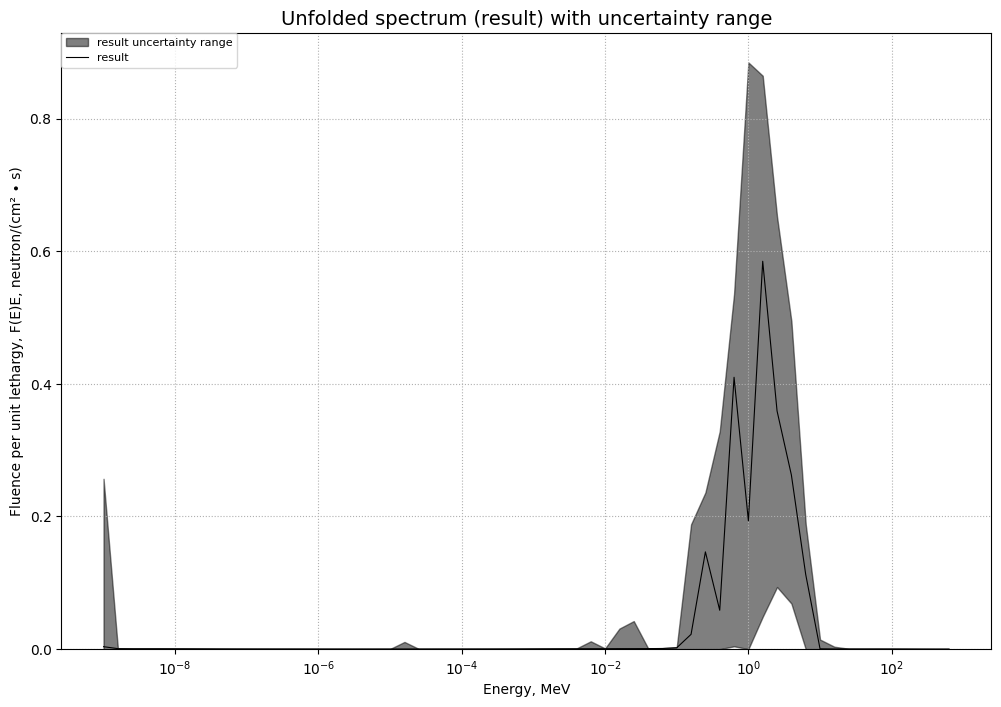

(<Figure size 1200x800 with 1 Axes>,
 <Axes: title={'center': 'Unfolded spectrum (result) with uncertainty range'}, xlabel='Energy, MeV', ylabel='Fluence per unit lethargy, F(E)E, neutron/(cm² ∙ s)'>)

In [8]:
det.plot_with_uncertainty(results['tikhonov+dp'])

In [9]:
results['tikhonov+dp']

{'energy': array([  1.00000000e-09,   1.58489319e-09,   2.51188643e-09,
          3.98107171e-09,   6.30957344e-09,   1.00000000e-08,
          1.58489319e-08,   2.51188643e-08,   3.98107171e-08,
          6.30957344e-08,   1.00000000e-07,   1.58489319e-07,
          2.51188643e-07,   3.98107171e-07,   6.30957344e-07,
          1.00000000e-06,   1.58489319e-06,   2.51188643e-06,
          3.98107171e-06,   6.30957344e-06,   1.00000000e-05,
          1.58489319e-05,   2.51188643e-05,   3.98107171e-05,
          6.30957344e-05,   1.00000000e-04,   1.58489319e-04,
          2.51188643e-04,   3.98107171e-04,   6.30957344e-04,
          1.00000000e-03,   1.58489319e-03,   2.51188643e-03,
          3.98107171e-03,   6.30957344e-03,   1.00000000e-02,
          1.58489319e-02,   2.51188643e-02,   3.98107171e-02,
          6.30957344e-02,   1.00000000e-01,   1.58489319e-01,
          2.51188643e-01,   3.98107171e-01,   6.30957344e-01,
          1.00000000e+00,   1.58489319e+00,   2.51188643e+00

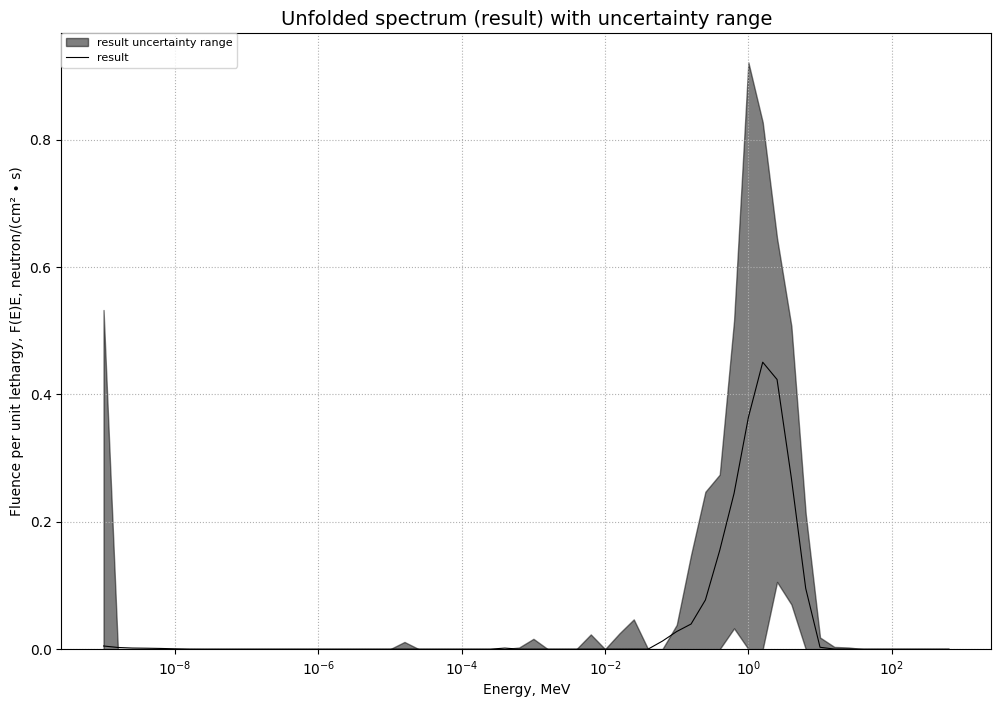

(<Figure size 1200x800 with 1 Axes>,
 <Axes: title={'center': 'Unfolded spectrum (result) with uncertainty range'}, xlabel='Energy, MeV', ylabel='Fluence per unit lethargy, F(E)E, neutron/(cm² ∙ s)'>)

In [10]:
det.plot_with_uncertainty(results['tikhonov+gcv'])

landweber with произвольный initial spectrum

In [11]:
sample_initial_spectrum =  {
    "E_MeV": [
        1e-09,
        1.5e-6,
        2.5e-4,
        1.1e-1,
        14,
        156,
        367,
    ],
    "Phi": [
        0.02,
        0.003,
        0.08,
        0.7,
        0.6,
        0.5,
        0.4,
    ],
}

result_landweber = det.unfold_landweber(readings, initial_spectrum= sample_initial_spectrum)

Result saved with key: 20260308_131558_Landweber


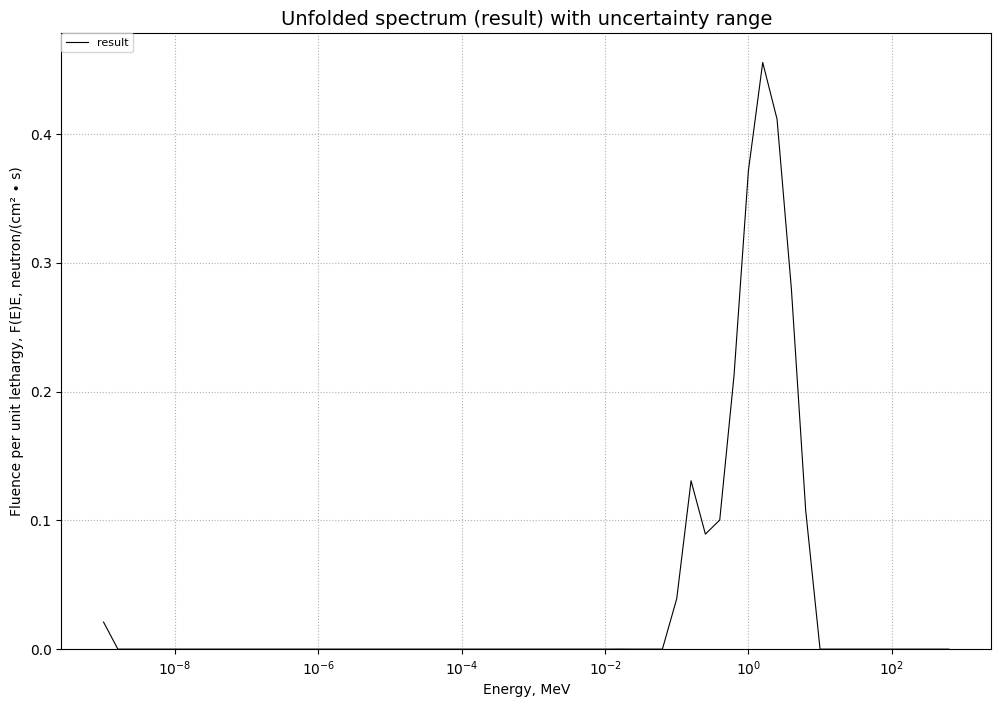

(<Figure size 1200x800 with 1 Axes>,
 <Axes: title={'center': 'Unfolded spectrum (result) with uncertainty range'}, xlabel='Energy, MeV', ylabel='Fluence per unit lethargy, F(E)E, neutron/(cm² ∙ s)'>)

In [12]:
det.plot_with_uncertainty(result_landweber)